In [1]:
from pathlib import Path

# Dataset root folder
dataset_root = (
    Path.home()
    / "OneDrive"
    / "Documents"
    / "NeuraSign_Datasets"
)

print("Dataset folder exists:", dataset_root.exists())
print("Dataset root:", dataset_root)

# Display folders and files containing SignAvatar-related names
matching_items = [
    item for item in dataset_root.rglob("*")
    if "avatar" in item.name.lower()
    or "word" in item.name.lower()
]

print("\nMatching items found:", len(matching_items))

for item in matching_items[:100]:
    item_type = "Folder" if item.is_dir() else "File"
    print(f"{item_type}: {item}")

Dataset folder exists: True
Dataset root: C:\Users\HP\OneDrive\Documents\NeuraSign_Datasets

Matching items found: 0


In [2]:
# Display all top-level files and folders
top_level_items = list(dataset_root.iterdir())

print("Total top-level items:", len(top_level_items))
print()

for item in top_level_items:
    if item.is_file():
        size_mb = round(item.stat().st_size / (1024 * 1024), 2)
        print(f"File   | {item.name} | {size_mb} MB")
    else:
        print(f"Folder | {item.name}")

Total top-level items: 21

File   | archive (3).zip | 4.38 MB
File   | ASL_Citizen.zip | 43796.67 MB
File   | corpus_0001.clean.zip | 66.78 MB
File   | corpus_0002.clean.zip | 43.91 MB
File   | corpus_0003.clean.zip | 53.15 MB
File   | corpus_0004.clean.zip | 75.51 MB
File   | corpus_0005.clean.zip | 361.78 MB
File   | corpus_0006.clean.zip | 242.59 MB
File   | corpus_0007.clean.zip | 62.71 MB
File   | corpus_0008.clean.zip | 0.06 MB
File   | corpus_0009.clean.zip | 0.47 MB
File   | corpus_0010.clean.zip | 8.87 MB
File   | corpus_0011.clean.zip | 2.78 MB
File   | corpus_0012.clean.zip | 77.28 MB
File   | corpus_0013.clean.zip | 209.67 MB
File   | corpus_0014.clean.zip | 169.65 MB
File   | corpus_0015.clean.zip | 130.64 MB
File   | corpus_0016.clean.zip | 70.0 MB
Folder | How2sign
Folder | processed
File   | wlasl_pkls_cropFalse_defult_shape.zip | 172.83 MB


In [3]:
import zipfile
from collections import Counter

signavatars_zip = (
    dataset_root
    / "wlasl_pkls_cropFalse_defult_shape.zip"
)

print("ZIP exists:", signavatars_zip.exists())
print("ZIP size:", round(signavatars_zip.stat().st_size / (1024 * 1024), 2), "MB")

with zipfile.ZipFile(signavatars_zip, "r") as zip_file:
    zip_items = [
        item for item in zip_file.infolist()
        if not item.is_dir()
    ]

print("\nTotal files inside ZIP:", len(zip_items))

# Count file extensions
extension_counts = Counter(
    Path(item.filename).suffix.lower()
    for item in zip_items
)

print("\nFile types:")
for extension, count in extension_counts.items():
    print(extension or "No extension", ":", count)

print("\nFirst 30 files:")
for item in zip_items[:30]:
    size_kb = round(item.file_size / 1024, 2)
    print(item.filename, "|", size_kb, "KB")

ZIP exists: True
ZIP size: 172.83 MB

Total files inside ZIP: 1000

File types:
.pkl : 1000

First 30 files:
wlasl_pkls_cropFalse_defult_shape/03071.pkl | 74.91 KB
wlasl_pkls_cropFalse_defult_shape/01836.pkl | 92.43 KB
wlasl_pkls_cropFalse_defult_shape/01625.pkl | 204.63 KB
wlasl_pkls_cropFalse_defult_shape/02234.pkl | 330.86 KB
wlasl_pkls_cropFalse_defult_shape/00425.pkl | 187.1 KB
wlasl_pkls_cropFalse_defult_shape/02880.pkl | 278.27 KB
wlasl_pkls_cropFalse_defult_shape/03634.pkl | 218.66 KB
wlasl_pkls_cropFalse_defult_shape/04052.pkl | 204.63 KB
wlasl_pkls_cropFalse_defult_shape/00842.pkl | 264.23 KB
wlasl_pkls_cropFalse_defult_shape/03366.pkl | 253.72 KB
wlasl_pkls_cropFalse_defult_shape/04304.pkl | 99.45 KB
wlasl_pkls_cropFalse_defult_shape/04130.pkl | 362.42 KB
wlasl_pkls_cropFalse_defult_shape/03205.pkl | 159.05 KB
wlasl_pkls_cropFalse_defult_shape/03004.pkl | 29.31 KB
wlasl_pkls_cropFalse_defult_shape/01965.pkl | 313.32 KB
wlasl_pkls_cropFalse_defult_shape/04015.pkl | 134.51 KB


In [4]:
import pickle
import numpy as np

with zipfile.ZipFile(signavatars_zip, "r") as zip_file:
    first_pkl_name = zip_items[0].filename

    with zip_file.open(first_pkl_name) as pkl_file:
        sample_data = pickle.load(pkl_file)

print("Sample file:", first_pkl_name)
print("Python object type:", type(sample_data))

if isinstance(sample_data, dict):
    print("\nAvailable keys:")

    for key, value in sample_data.items():
        if hasattr(value, "shape"):
            print(
                f"{key}: type={type(value).__name__}, "
                f"shape={value.shape}, dtype={value.dtype}"
            )
        elif isinstance(value, (list, tuple)):
            print(
                f"{key}: type={type(value).__name__}, "
                f"length={len(value)}"
            )
        else:
            preview = str(value)[:100]
            print(
                f"{key}: type={type(value).__name__}, "
                f"value={preview}"
            )
else:
    if hasattr(sample_data, "shape"):
        print("Shape:", sample_data.shape)
        print("Data type:", sample_data.dtype)
    else:
        print("Preview:", str(sample_data)[:500])

ModuleNotFoundError: No module named 'torch'

In [ ]:
from pathlib import Path
import zipfile
import pickle
import torch
import numpy as np

# Restore dataset paths after kernel restart
dataset_root = (
    Path.home()
    / "OneDrive"
    / "Documents"
    / "NeuraSign_Datasets"
)

signavatars_zip = (
    dataset_root
    / "wlasl_pkls_cropFalse_defult_shape.zip"
)

# Read PKL file names from ZIP
with zipfile.ZipFile(signavatars_zip, "r") as zip_file:
    pkl_files = [
        item.filename
        for item in zip_file.infolist()
        if not item.is_dir()
        and item.filename.lower().endswith(".pkl")
    ]

    first_pkl_name = pkl_files[0]

    with zip_file.open(first_pkl_name) as pkl_file:
      sample_data = pickle.load(pkl_file)

print("PyTorch version:", torch.__version__)
print("Total PKL files:", len(pkl_files))
print("Sample file:", first_pkl_name)
print("Object type:", type(sample_data))

if isinstance(sample_data, dict):
    print("\nAvailable keys and shapes:")

    for key, value in sample_data.items():
        if isinstance(value, torch.Tensor):
            print(
                f"{key}: Torch tensor, "
                f"shape={tuple(value.shape)}, "
                f"dtype={value.dtype}"
            )
        elif isinstance(value, np.ndarray):
            print(
                f"{key}: NumPy array, "
                f"shape={value.shape}, "
                f"dtype={value.dtype}"
            )
        elif isinstance(value, (list, tuple)):
            print(
                f"{key}: {type(value).__name__}, "
                f"length={len(value)}"
            )
        else:
            print(
                f"{key}: {type(value).__name__}, "
                f"value={str(value)[:100]}"
            )
else:
    print("Sample preview:", str(sample_data)[:500])

TypeError: 'map_location' is an invalid keyword argument for load()

In [2]:
from pathlib import Path
import zipfile
import pickle
import torch
import numpy as np

# Set dataset folder path
dataset_root = (
    Path.home()
    / "OneDrive"
    / "Documents"
    / "NeuraSign_Datasets"
)

# Set SignAvatars ZIP file path
signavatars_zip = (
    dataset_root
    / "wlasl_pkls_cropFalse_defult_shape.zip"
)

# Open ZIP and load one PKL sample
with zipfile.ZipFile(signavatars_zip, "r") as zip_file:
    pkl_files = [
        item.filename
        for item in zip_file.infolist()
        if not item.is_dir()
        and item.filename.lower().endswith(".pkl")
    ]

    first_pkl_name = pkl_files[0]

    with zip_file.open(first_pkl_name) as pkl_file:
        sample_data = pickle.load(pkl_file)

# Display basic information
print("PyTorch version:", torch.__version__)
print("ZIP exists:", signavatars_zip.exists())
print("Total PKL files:", len(pkl_files))
print("Sample file:", first_pkl_name)
print("Object type:", type(sample_data))

# Display keys, data types and shapes
if isinstance(sample_data, dict):
    print("\nAvailable keys and shapes:")

    for key, value in sample_data.items():

        if isinstance(value, torch.Tensor):
            print(
                f"{key}: Torch Tensor, "
                f"shape={tuple(value.shape)}, "
                f"dtype={value.dtype}"
            )

        elif isinstance(value, np.ndarray):
            print(
                f"{key}: NumPy Array, "
                f"shape={value.shape}, "
                f"dtype={value.dtype}"
            )

        elif isinstance(value, (list, tuple)):
            print(
                f"{key}: {type(value).__name__}, "
                f"length={len(value)}"
            )

        else:
            print(
                f"{key}: {type(value).__name__}, "
                f"value={str(value)[:100]}"
            )

else:
    print("\nSample data is not a dictionary.")

    if hasattr(sample_data, "shape"):
        print("Shape:", sample_data.shape)

    print("Preview:", str(sample_data)[:500])

RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("PyTorch CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

    test_tensor = torch.rand(3, 3).cuda()
    print("Tensor device:", test_tensor.device)
    print(test_tensor)
    

PyTorch version: 2.14.0+cu130
PyTorch CUDA version: 13.0
CUDA available: True
GPU: NVIDIA T500
Tensor device: cuda:0
tensor([[0.9263, 0.2500, 0.3197],
        [0.3965, 0.2620, 0.7424],
        [0.4518, 0.9257, 0.0867]], device='cuda:0')


In [1]:
from pathlib import Path
import zipfile
import pickle
import torch
import numpy as np

# Check GPU setup
print("PyTorch version:", torch.__version__)
print("PyTorch CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is still not available. Restart the VS Code kernel and try again."
    )

print("GPU name:", torch.cuda.get_device_name(0))

# Set dataset paths
dataset_root = (
    Path.home()
    / "OneDrive"
    / "Documents"
    / "NeuraSign_Datasets"
)

signavatars_zip = (
    dataset_root
    / "wlasl_pkls_cropFalse_defult_shape.zip"
)

# Load one PKL sample
with zipfile.ZipFile(signavatars_zip, "r") as zip_file:

    pkl_files = [
        item.filename
        for item in zip_file.infolist()
        if not item.is_dir()
        and item.filename.lower().endswith(".pkl")
    ]

    first_pkl_name = pkl_files[0]

    with zip_file.open(first_pkl_name) as pkl_file:
        sample_data = pickle.load(pkl_file)

print("\nTotal PKL files:", len(pkl_files))
print("Sample file:", first_pkl_name)
print("Object type:", type(sample_data))

# Display keys and shapes
if isinstance(sample_data, dict):

    print("\nAvailable keys and shapes:")

    for key, value in sample_data.items():

        if isinstance(value, torch.Tensor):
            print(
                f"{key}: Torch Tensor, "
                f"shape={tuple(value.shape)}, "
                f"dtype={value.dtype}, "
                f"device={value.device}"
            )

        elif isinstance(value, np.ndarray):
            print(
                f"{key}: NumPy Array, "
                f"shape={value.shape}, "
                f"dtype={value.dtype}"
            )

        elif isinstance(value, (list, tuple)):
            print(
                f"{key}: {type(value).__name__}, "
                f"length={len(value)}"
            )

        else:
            print(
                f"{key}: {type(value).__name__}, "
                f"value={str(value)[:100]}"
            )

PyTorch version: 2.14.0+cu130
PyTorch CUDA version: 13.0
CUDA available: True
GPU name: NVIDIA T500

Total PKL files: 1000
Sample file: wlasl_pkls_cropFalse_defult_shape/03071.pkl
Object type: <class 'dict'>

Available keys and shapes:
left_valid: Torch Tensor, shape=(21,), dtype=torch.bool, device=cuda:0
right_valid: Torch Tensor, shape=(21,), dtype=torch.bool, device=cuda:0
total_valid_index: NumPy Array, shape=(21,), dtype=int64
2d: NumPy Array, shape=(21, 106, 3), dtype=float32
pred_2d: NumPy Array, shape=(21, 106, 2), dtype=float32
smplx: NumPy Array, shape=(21, 182), dtype=float32
unsmooth_smplx: NumPy Array, shape=(21, 169), dtype=float32
bb2img_trans: NumPy Array, shape=(21, 2, 3), dtype=float32
focal: NumPy Array, shape=(21, 2), dtype=float64
princpt: NumPy Array, shape=(21, 2), dtype=float64


In [2]:
from pathlib import Path
from urllib.request import urlretrieve

# Official WLASL metadata URL
metadata_url = (
    "https://raw.githubusercontent.com/"
    "dxli94/WLASL/master/start_kit/WLASL_v0.3.json"
)

# Save metadata beside the downloaded ZIP
metadata_path = dataset_root / "WLASL_v0.3.json"

if metadata_path.exists():
    print("Metadata already exists:")
    print(metadata_path)
else:
    urlretrieve(metadata_url, metadata_path)

    print("Metadata downloaded successfully:")
    print(metadata_path)

print(
    "Metadata size:",
    round(metadata_path.stat().st_size / (1024 * 1024), 2),
    "MB"
)

Metadata downloaded successfully:
C:\Users\HP\OneDrive\Documents\NeuraSign_Datasets\WLASL_v0.3.json
Metadata size: 11.38 MB


In [3]:
import json
import pandas as pd
from pathlib import Path

# Load official WLASL metadata
with open(metadata_path, "r", encoding="utf-8") as file:
    wlasl_metadata = json.load(file)

print("Total gloss classes in metadata:", len(wlasl_metadata))

# Convert nested JSON into a flat table
metadata_records = []

for gloss_entry in wlasl_metadata:

    gloss = gloss_entry["gloss"]

    for instance in gloss_entry["instances"]:

        metadata_records.append({
            "video_id": str(instance["video_id"]).zfill(5),
            "gloss": gloss,
            "split": instance.get("split"),
            "signer_id": instance.get("signer_id"),
            "fps": instance.get("fps"),
            "frame_start": instance.get("frame_start"),
            "frame_end": instance.get("frame_end")
        })

metadata_df = pd.DataFrame(metadata_records)

print("Total metadata video records:", len(metadata_df))
print("Unique glosses:", metadata_df["gloss"].nunique())

# Create table of PKL files
pkl_records = []

for pkl_name in pkl_files:

    video_id = Path(pkl_name).stem.zfill(5)

    pkl_records.append({
        "video_id": video_id,
        "pkl_path": pkl_name
    })

pkl_df = pd.DataFrame(pkl_records)

# Match PKL IDs with labels
matched_df = pkl_df.merge(
    metadata_df,
    on="video_id",
    how="left"
)

matched_count = matched_df["gloss"].notna().sum()
missing_count = matched_df["gloss"].isna().sum()

print("\nPKL samples:", len(matched_df))
print("Samples with valid labels:", matched_count)
print("Samples without labels:", missing_count)
print("Unique matched glosses:", matched_df["gloss"].nunique())

print("\nMatched sample preview:")
display(matched_df.head(10))

if missing_count > 0:
    print("\nPKL IDs without matching labels:")
    display(
        matched_df.loc[
            matched_df["gloss"].isna(),
            ["video_id", "pkl_path"]
        ].head(20)
    )

Total gloss classes in metadata: 2000
Total metadata video records: 21083
Unique glosses: 2000

PKL samples: 1000
Samples with valid labels: 1000
Samples without labels: 0
Unique matched glosses: 124

Matched sample preview:


,video_id,pkl_path,gloss,split,signer_id,fps,frame_start,frame_end
0,03071,wlasl_pkls_cropFalse_defult_shape/03071.pkl,appreciate,train,55,25,1,-1
1,01836,wlasl_pkls_cropFalse_defult_shape/01836.pkl,alcohol,train,11,25,1,-1
2,01625,wlasl_pkls_cropFalse_defult_shape/01625.pkl,aid,train,14,25,1,-1
3,02234,wlasl_pkls_cropFalse_defult_shape/02234.pkl,always,train,5,25,1,-1
4,00425,wlasl_pkls_cropFalse_defult_shape/00425.pkl,about,train,16,25,1,-1
5,02880,wlasl_pkls_cropFalse_defult_shape/02880.pkl,apartment,train,12,25,1,-1
6,03634,wlasl_pkls_cropFalse_defult_shape/03634.pkl,asl,train,37,25,1,-1
7,04052,wlasl_pkls_cropFalse_defult_shape/04052.pkl,attorney,train,20,25,1,-1
8,00842,wlasl_pkls_cropFalse_defult_shape/00842.pkl,across,train,12,25,1,-1
9,03366,wlasl_pkls_cropFalse_defult_shape/03366.pkl,army,train,5,25,1,-1


In [4]:
# Keep only PKL samples with valid labels
clean_metadata_df = matched_df.dropna(
    subset=["gloss"]
).copy()

# Clean text columns
clean_metadata_df["gloss"] = (
    clean_metadata_df["gloss"]
    .astype(str)
    .str.strip()
    .str.lower()
)

clean_metadata_df["split"] = (
    clean_metadata_df["split"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Check duplicate video IDs
duplicate_video_ids = clean_metadata_df[
    clean_metadata_df.duplicated(
        subset=["video_id"],
        keep=False
    )
]

print("Valid labeled samples:", len(clean_metadata_df))
print("Unique video IDs:", clean_metadata_df["video_id"].nunique())
print("Duplicate video IDs:", len(duplicate_video_ids))
print("Unique gloss classes:", clean_metadata_df["gloss"].nunique())

print("\nOfficial split distribution:")
display(
    clean_metadata_df["split"]
    .value_counts(dropna=False)
    .rename_axis("split")
    .reset_index(name="sample_count")
)

print("\nGloss class distribution:")
gloss_distribution = (
    clean_metadata_df["gloss"]
    .value_counts()
    .rename_axis("gloss")
    .reset_index(name="sample_count")
)

display(gloss_distribution.head(30))

print("\nSamples per gloss summary:")
display(
    gloss_distribution["sample_count"]
    .describe()
    .to_frame(name="value")
)

Valid labeled samples: 1000
Unique video IDs: 1000
Duplicate video IDs: 0
Unique gloss classes: 124

Official split distribution:


,split,sample_count
0,train,670
1,val,190
2,test,140



Gloss class distribution:


,gloss,sample_count
0,accident,17
1,approve,15
2,africa,15
3,all,15
4,argue,13
5,always,12
6,ago,12
7,again,12
8,arrive,12
9,about,11



Samples per gloss summary:


,value
count,124.000000
mean,8.064516
std,2.192900
min,4.000000
25%,7.000000
50%,8.000000
75%,9.000000
max,17.000000


In [5]:
from tqdm.auto import tqdm
import pandas as pd
import pickle
import torch
from pathlib import Path

feature_records = []
failed_records = []

with zipfile.ZipFile(signavatars_zip, "r") as zip_file:

    for index, pkl_name in enumerate(
        tqdm(
            pkl_files,
            desc="Extracting GPU motion features"
        )
    ):

        video_id = Path(pkl_name).stem.zfill(5)

        try:
            # Load one motion sample
            with zip_file.open(pkl_name) as pkl_file:
                motion_sample = pickle.load(pkl_file)

            # Extract numerical features on GPU
            features = extract_motion_features(
                motion_sample
            )

            features["video_id"] = video_id
            features["pkl_path"] = pkl_name

            feature_records.append(features)

            # Release GPU memory
            del motion_sample

            if (index + 1) % 100 == 0:
                torch.cuda.empty_cache()

        except Exception as error:

            failed_records.append({
                "video_id": video_id,
                "pkl_path": pkl_name,
                "error": str(error)
            })

# Convert extracted features into a table
features_df = pd.DataFrame(feature_records)
failed_df = pd.DataFrame(failed_records)

print("\nFeature extraction completed.")
print("Successful samples:", len(features_df))
print("Failed samples:", len(failed_df))

display(features_df.head())

if not failed_df.empty:
    print("\nFailed file details:")
    display(failed_df.head(20))

    

Extracting GPU motion features:   0%|          | 0/1000 [00:00<?, ?it/s]


Feature extraction completed.
Successful samples: 0
Failed samples: 1000


""



Failed file details:


,video_id,pkl_path,error
0,03071,wlasl_pkls_cropFalse_defult_shape/03071.pkl,name 'extract_motion_features' is not defined
1,01836,wlasl_pkls_cropFalse_defult_shape/01836.pkl,name 'extract_motion_features' is not defined
2,01625,wlasl_pkls_cropFalse_defult_shape/01625.pkl,name 'extract_motion_features' is not defined
3,02234,wlasl_pkls_cropFalse_defult_shape/02234.pkl,name 'extract_motion_features' is not defined
4,00425,wlasl_pkls_cropFalse_defult_shape/00425.pkl,name 'extract_motion_features' is not defined
5,02880,wlasl_pkls_cropFalse_defult_shape/02880.pkl,name 'extract_motion_features' is not defined
6,03634,wlasl_pkls_cropFalse_defult_shape/03634.pkl,name 'extract_motion_features' is not defined
7,04052,wlasl_pkls_cropFalse_defult_shape/04052.pkl,name 'extract_motion_features' is not defined
8,00842,wlasl_pkls_cropFalse_defult_shape/00842.pkl,name 'extract_motion_features' is not defined
9,03366,wlasl_pkls_cropFalse_defult_shape/03366.pkl,name 'extract_motion_features' is not defined


In [6]:
from pathlib import Path
import zipfile
import pickle

import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm


# Select NVIDIA GPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Processing device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


def extract_motion_features(sample):

    # Convert raw arrays to GPU tensors
    keypoints_2d = torch.as_tensor(
        sample["2d"],
        dtype=torch.float32,
        device=device
    )

    smplx = torch.as_tensor(
        sample["smplx"],
        dtype=torch.float32,
        device=device
    )

    left_valid = torch.as_tensor(
        sample["left_valid"],
        dtype=torch.float32,
        device=device
    )

    right_valid = torch.as_tensor(
        sample["right_valid"],
        dtype=torch.float32,
        device=device
    )

    frame_count = keypoints_2d.shape[0]

    # Separate coordinates and confidence values
    coordinates = keypoints_2d[:, :, :2]
    confidence = keypoints_2d[:, :, 2]

    # Calculate motion between consecutive frames
    if frame_count > 1:

        coordinate_difference = (
            coordinates[1:] - coordinates[:-1]
        )

        movement = torch.linalg.norm(
            coordinate_difference,
            dim=2
        )

        smplx_difference = (
            smplx[1:] - smplx[:-1]
        )

        mean_2d_motion = movement.mean().item()
        maximum_2d_motion = movement.max().item()
        std_2d_motion = movement.std().item()

        mean_smplx_motion = (
            torch.abs(smplx_difference)
            .mean()
            .item()
        )

        maximum_smplx_motion = (
            torch.abs(smplx_difference)
            .max()
            .item()
        )

    else:

        mean_2d_motion = 0.0
        maximum_2d_motion = 0.0
        std_2d_motion = 0.0
        mean_smplx_motion = 0.0
        maximum_smplx_motion = 0.0

    return {
        "frame_count": int(frame_count),
        "left_hand_valid_ratio": left_valid.mean().item(),
        "right_hand_valid_ratio": right_valid.mean().item(),
        "mean_keypoint_confidence": confidence.mean().item(),
        "minimum_keypoint_confidence": confidence.min().item(),
        "mean_2d_motion": mean_2d_motion,
        "maximum_2d_motion": maximum_2d_motion,
        "std_2d_motion": std_2d_motion,
        "mean_smplx_value": smplx.mean().item(),
        "std_smplx_value": smplx.std().item(),
        "mean_smplx_motion": mean_smplx_motion,
        "maximum_smplx_motion": maximum_smplx_motion
    }


# Reset old failed results
feature_records = []
failed_records = []

# Process all PKL files
with zipfile.ZipFile(signavatars_zip, "r") as zip_file:

    for index, pkl_name in enumerate(
        tqdm(
            pkl_files,
            desc="Extracting motion features"
        )
    ):

        video_id = Path(pkl_name).stem.zfill(5)

        try:

            with zip_file.open(pkl_name) as pkl_file:
                motion_sample = pickle.load(pkl_file)

            features = extract_motion_features(
                motion_sample
            )

            features["video_id"] = video_id
            features["pkl_path"] = pkl_name

            feature_records.append(features)

            del motion_sample

            if (index + 1) % 100 == 0:
                torch.cuda.empty_cache()

        except Exception as error:

            failed_records.append({
                "video_id": video_id,
                "pkl_path": pkl_name,
                "error": str(error)
            })


# Create result tables
features_df = pd.DataFrame(feature_records)
failed_df = pd.DataFrame(failed_records)

print("\nFeature extraction completed.")
print("Successful samples:", len(features_df))
print("Failed samples:", len(failed_df))

display(features_df.head())

if not failed_df.empty:
    display(failed_df.head(20))

Processing device: cuda
GPU: NVIDIA T500


Extracting motion features:   0%|          | 0/1000 [00:00<?, ?it/s]


Feature extraction completed.
Successful samples: 1000
Failed samples: 0


,frame_count,left_hand_valid_ratio,right_hand_valid_ratio,mean_keypoint_confidence,minimum_keypoint_confidence,mean_2d_motion,maximum_2d_motion,std_2d_motion,mean_smplx_value,std_smplx_value,mean_smplx_motion,maximum_smplx_motion,video_id,pkl_path
0,21,1.000000,1.000000,0.923144,0.652445,1.345436,17.457335,1.839567,0.117211,1.733830,0.016529,1.635502,03071,wlasl_pkls_cropFalse_defult_shape/03071.pkl
1,26,1.000000,1.000000,0.934309,0.605822,0.931862,17.341574,1.611978,0.076094,1.380829,0.010449,0.459022,01836,wlasl_pkls_cropFalse_defult_shape/01836.pkl
2,58,0.948276,1.000000,0.752751,0.052171,7.858099,209.134583,31.310810,0.112777,1.434681,0.013253,1.848639,01625,wlasl_pkls_cropFalse_defult_shape/01625.pkl
3,94,0.702128,0.765957,0.774309,0.038538,5.315910,238.348953,23.902637,0.127110,1.467695,0.011789,2.286104,02234,wlasl_pkls_cropFalse_defult_shape/02234.pkl
4,53,0.716981,0.830189,0.845812,0.048059,7.167256,199.598373,24.020857,0.081088,1.374119,0.022692,2.464720,00425,wlasl_pkls_cropFalse_defult_shape/00425.pkl


In [7]:
# Merge motion features with official WLASL metadata
model_df = features_df.merge(
    clean_metadata_df[
        [
            "video_id",
            "gloss",
            "split",
            "signer_id",
            "fps",
            "frame_start",
            "frame_end"
        ]
    ],
    on="video_id",
    how="inner"
)

print("Records after merge:", len(model_df))
print("Unique video IDs:", model_df["video_id"].nunique())
print("Unique gloss classes:", model_df["gloss"].nunique())

# Remove exact duplicate rows
records_before = len(model_df)

model_df = model_df.drop_duplicates(
    subset=["video_id"],
    keep="first"
).reset_index(drop=True)

records_after = len(model_df)

print("Duplicates removed:", records_before - records_after)

# Replace infinite values with missing values
model_df = model_df.replace(
    [np.inf, -np.inf],
    np.nan
)

# Check missing values
missing_summary = (
    model_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nMissing values:")
display(
    missing_summary[
        missing_summary > 0
    ].to_frame(name="missing_count")
)

print("\nOfficial split distribution:")
display(
    model_df["split"]
    .value_counts()
    .rename_axis("split")
    .reset_index(name="sample_count")
)

print("\nModel-ready preview:")
display(model_df.head())

Records after merge: 1000
Unique video IDs: 1000
Unique gloss classes: 124
Duplicates removed: 0

Missing values:


,missing_count



Official split distribution:


,split,sample_count
0,train,670
1,val,190
2,test,140



Model-ready preview:


,frame_count,left_hand_valid_ratio,right_hand_valid_ratio,mean_keypoint_confidence,minimum_keypoint_confidence,mean_2d_motion,maximum_2d_motion,std_2d_motion,mean_smplx_value,std_smplx_value,mean_smplx_motion,maximum_smplx_motion,video_id,pkl_path,gloss,split,signer_id,fps,frame_start,frame_end
0,21,1.000000,1.000000,0.923144,0.652445,1.345436,17.457335,1.839567,0.117211,1.733830,0.016529,1.635502,03071,wlasl_pkls_cropFalse_defult_shape/03071.pkl,appreciate,train,55,25,1,-1
1,26,1.000000,1.000000,0.934309,0.605822,0.931862,17.341574,1.611978,0.076094,1.380829,0.010449,0.459022,01836,wlasl_pkls_cropFalse_defult_shape/01836.pkl,alcohol,train,11,25,1,-1
2,58,0.948276,1.000000,0.752751,0.052171,7.858099,209.134583,31.310810,0.112777,1.434681,0.013253,1.848639,01625,wlasl_pkls_cropFalse_defult_shape/01625.pkl,aid,train,14,25,1,-1
3,94,0.702128,0.765957,0.774309,0.038538,5.315910,238.348953,23.902637,0.127110,1.467695,0.011789,2.286104,02234,wlasl_pkls_cropFalse_defult_shape/02234.pkl,always,train,5,25,1,-1
4,53,0.716981,0.830189,0.845812,0.048059,7.167256,199.598373,24.020857,0.081088,1.374119,0.022692,2.464720,00425,wlasl_pkls_cropFalse_defult_shape/00425.pkl,about,train,16,25,1,-1


In [8]:
# Features used by the ID3 model
feature_columns = [
    "frame_count",
    "left_hand_valid_ratio",
    "right_hand_valid_ratio",
    "mean_keypoint_confidence",
    "minimum_keypoint_confidence",
    "mean_2d_motion",
    "maximum_2d_motion",
    "std_2d_motion",
    "mean_smplx_value",
    "std_smplx_value",
    "mean_smplx_motion",
    "maximum_smplx_motion"
]

# Create official splits
train_df = model_df[
    model_df["split"] == "train"
].copy()

val_df = model_df[
    model_df["split"] == "val"
].copy()

test_df = model_df[
    model_df["split"] == "test"
].copy()

# Separate features and target labels
X_train = train_df[feature_columns].copy()
y_train = train_df["gloss"].copy()

X_val = val_df[feature_columns].copy()
y_val = val_df["gloss"].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df["gloss"].copy()

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

print("\nTraining classes:", y_train.nunique())
print("Validation classes:", y_val.nunique())
print("Test classes:", y_test.nunique())

# Check whether validation or test contains unseen classes
train_classes = set(y_train.unique())
validation_classes = set(y_val.unique())
test_classes = set(y_test.unique())

unseen_validation_classes = (
    validation_classes - train_classes
)

unseen_test_classes = (
    test_classes - train_classes
)

print(
    "\nValidation classes absent from training:",
    len(unseen_validation_classes)
)

print(
    "Test classes absent from training:",
    len(unseen_test_classes)
)

if unseen_validation_classes:
    print(sorted(unseen_validation_classes))

if unseen_test_classes:
    print(sorted(unseen_test_classes))

Training samples: 670
Validation samples: 190
Test samples: 140

Training classes: 124
Validation classes: 117
Test classes: 107

Validation classes absent from training: 0
Test classes absent from training: 0


In [9]:
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# Features where extreme numerical values can occur
outlier_features = [
    "frame_count",
    "mean_2d_motion",
    "maximum_2d_motion",
    "std_2d_motion",
    "mean_smplx_value",
    "std_smplx_value",
    "mean_smplx_motion",
    "maximum_smplx_motion"
]

# Learn outlier limits only from training data
outlier_bounds = {}

for feature in outlier_features:

    first_quartile = X_train[feature].quantile(0.25)
    third_quartile = X_train[feature].quantile(0.75)

    iqr = third_quartile - first_quartile

    lower_bound = first_quartile - (1.5 * iqr)
    upper_bound = third_quartile + (1.5 * iqr)

    outlier_bounds[feature] = {
        "lower": float(lower_bound),
        "upper": float(upper_bound)
    }

# Apply training bounds to every split
def apply_outlier_bounds(dataframe, bounds):

    processed_dataframe = dataframe.copy()

    for feature, limits in bounds.items():

        processed_dataframe[feature] = (
            processed_dataframe[feature]
            .clip(
                lower=limits["lower"],
                upper=limits["upper"]
            )
        )

    return processed_dataframe


X_train_clipped = apply_outlier_bounds(
    X_train,
    outlier_bounds
)

X_val_clipped = apply_outlier_bounds(
    X_val,
    outlier_bounds
)

X_test_clipped = apply_outlier_bounds(
    X_test,
    outlier_bounds
)

# Learn missing-value replacement only from training data
imputer = SimpleImputer(strategy="median")

X_train_processed = pd.DataFrame(
    imputer.fit_transform(X_train_clipped),
    columns=feature_columns,
    index=X_train.index
)

X_val_processed = pd.DataFrame(
    imputer.transform(X_val_clipped),
    columns=feature_columns,
    index=X_val.index
)

X_test_processed = pd.DataFrame(
    imputer.transform(X_test_clipped),
    columns=feature_columns,
    index=X_test.index
)

print("Preprocessing completed successfully.")

print(
    "Training missing values:",
    X_train_processed.isna().sum().sum()
)

print(
    "Validation missing values:",
    X_val_processed.isna().sum().sum()
)

print(
    "Test missing values:",
    X_test_processed.isna().sum().sum()
)

print("\nProcessed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Preprocessing completed successfully.
Training missing values: 0
Validation missing values: 0
Test missing values: 0

Processed training shape: (670, 12)
Processed validation shape: (190, 12)
Processed test shape: (140, 12)


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

depth_values = [5, 10, 15, 20, None]
leaf_values = [1, 2, 3, 5]

validation_results = []

best_model = None
best_validation_f1 = -1
best_parameters = None

for depth in depth_values:

    for minimum_leaf in leaf_values:

        # Entropy uses information gain like ID3
        model = DecisionTreeClassifier(
            criterion="entropy",
            max_depth=depth,
            min_samples_leaf=minimum_leaf,
            class_weight="balanced",
            random_state=42
        )

        # Train only on the official training split
        model.fit(
            X_train_processed,
            y_train
        )

        # Evaluate on validation data
        validation_predictions = model.predict(
            X_val_processed
        )

        validation_accuracy = accuracy_score(
            y_val,
            validation_predictions
        )

        validation_f1 = f1_score(
            y_val,
            validation_predictions,
            average="macro",
            zero_division=0
        )

        validation_results.append({
            "max_depth": (
                depth if depth is not None else "Full"
            ),
            "min_samples_leaf": minimum_leaf,
            "validation_accuracy": validation_accuracy,
            "validation_macro_f1": validation_f1,
            "tree_nodes": model.tree_.node_count,
            "tree_depth": model.tree_.max_depth
        })

        # Select model using macro F1
        if validation_f1 > best_validation_f1:

            best_validation_f1 = validation_f1
            best_model = model

            best_parameters = {
                "max_depth": depth,
                "min_samples_leaf": minimum_leaf
            }

# Sort validation results
validation_results_df = pd.DataFrame(
    validation_results
).sort_values(
    by="validation_macro_f1",
    ascending=False
).reset_index(drop=True)

print("Best parameters:")
print(best_parameters)

print(
    "\nBest validation macro F1:",
    round(best_validation_f1, 4)
)

display(validation_results_df)

Best parameters:
{'max_depth': 15, 'min_samples_leaf': 1}

Best validation macro F1: 0.0265


,max_depth,min_samples_leaf,validation_accuracy,validation_macro_f1,tree_nodes,tree_depth
0,Full,1,0.031579,0.026503,1077,11
1,15,1,0.031579,0.026503,1077,11
2,20,1,0.031579,0.026503,1077,11
3,10,1,0.026316,0.022131,1049,10
4,15,3,0.026316,0.018761,355,9
5,Full,3,0.026316,0.018761,355,9
6,10,3,0.026316,0.018761,355,9
7,20,3,0.026316,0.018761,355,9
8,20,2,0.021053,0.016940,557,10
9,Full,2,0.021053,0.016940,557,10


In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    top_k_accuracy_score
)

# Make final predictions
test_predictions = best_model.predict(
    X_test_processed
)

test_probabilities = best_model.predict_proba(
    X_test_processed
)

# Calculate evaluation metrics
test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_precision = precision_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

# Top-k accuracy is useful for many-class recognition
test_top3_accuracy = top_k_accuracy_score(
    y_test,
    test_probabilities,
    k=3,
    labels=best_model.classes_
)

test_top5_accuracy = top_k_accuracy_score(
    y_test,
    test_probabilities,
    k=5,
    labels=best_model.classes_
)

print("Final SignAvatars ID3 Test Results")
print("---------------------------------")
print("Accuracy:", round(test_accuracy, 4))
print("Macro Precision:", round(test_precision, 4))
print("Macro Recall:", round(test_recall, 4))
print("Macro F1 Score:", round(test_f1, 4))
print("Top-3 Accuracy:", round(test_top3_accuracy, 4))
print("Top-5 Accuracy:", round(test_top5_accuracy, 4))

# Create detailed class report
class_report = classification_report(
    y_test,
    test_predictions,
    output_dict=True,
    zero_division=0
)

class_report_df = (
    pd.DataFrame(class_report)
    .transpose()
)

print("\nClassification report preview:")
display(class_report_df.head(20))

Final SignAvatars ID3 Test Results
---------------------------------
Accuracy: 0.0143
Macro Precision: 0.0116
Macro Recall: 0.013
Macro F1 Score: 0.0122
Top-3 Accuracy: 0.0214
Top-5 Accuracy: 0.0357

Classification report preview:


,precision,recall,f1-score,support
a lot,0.0,0.0,0.0,1.0
abdomen,0.0,0.0,0.0,1.0
able,0.0,0.0,0.0,1.0
about,0.0,0.0,0.0,1.0
above,0.0,0.0,0.0,1.0
accent,0.0,0.0,0.0,1.0
accept,0.0,0.0,0.0,2.0
accident,0.0,0.0,0.0,3.0
accomplish,0.0,0.0,0.0,1.0
accountant,0.0,0.0,0.0,1.0


Feature importance:


,feature,importance
0,mean_smplx_value,0.205493
1,mean_keypoint_confidence,0.139371
2,std_smplx_value,0.134521
3,mean_smplx_motion,0.102255
4,maximum_smplx_motion,0.092979
5,frame_count,0.085376
6,minimum_keypoint_confidence,0.052501
7,std_2d_motion,0.047666
8,mean_2d_motion,0.045800
9,maximum_2d_motion,0.044234


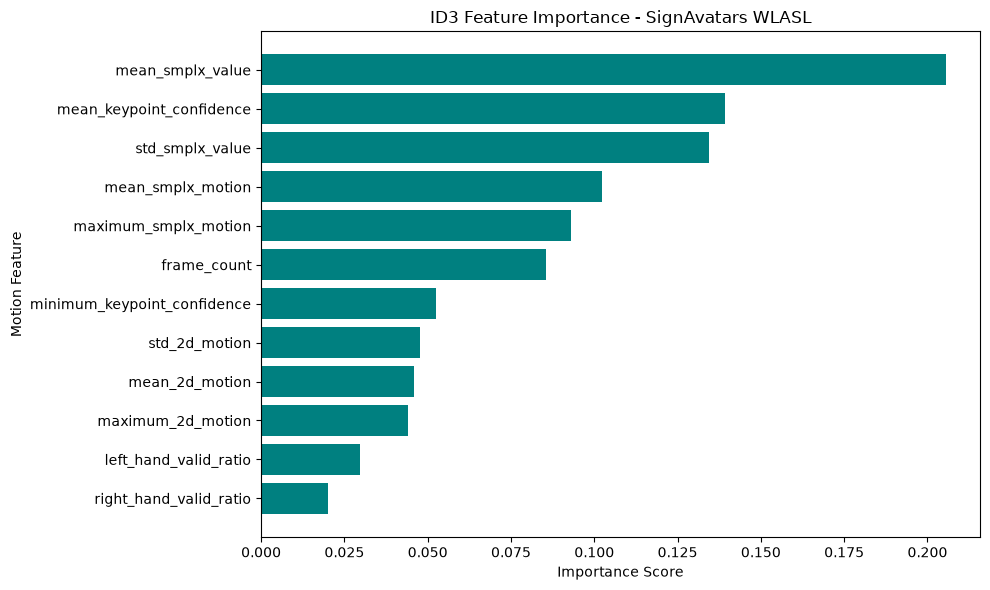

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Create feature importance table
feature_importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": best_model.feature_importances_
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Feature importance:")
display(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["feature"],
    feature_importance_df["importance"],
    color="teal"
)

plt.xlabel("Importance Score")
plt.ylabel("Motion Feature")
plt.title(
    "ID3 Feature Importance - SignAvatars WLASL"
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

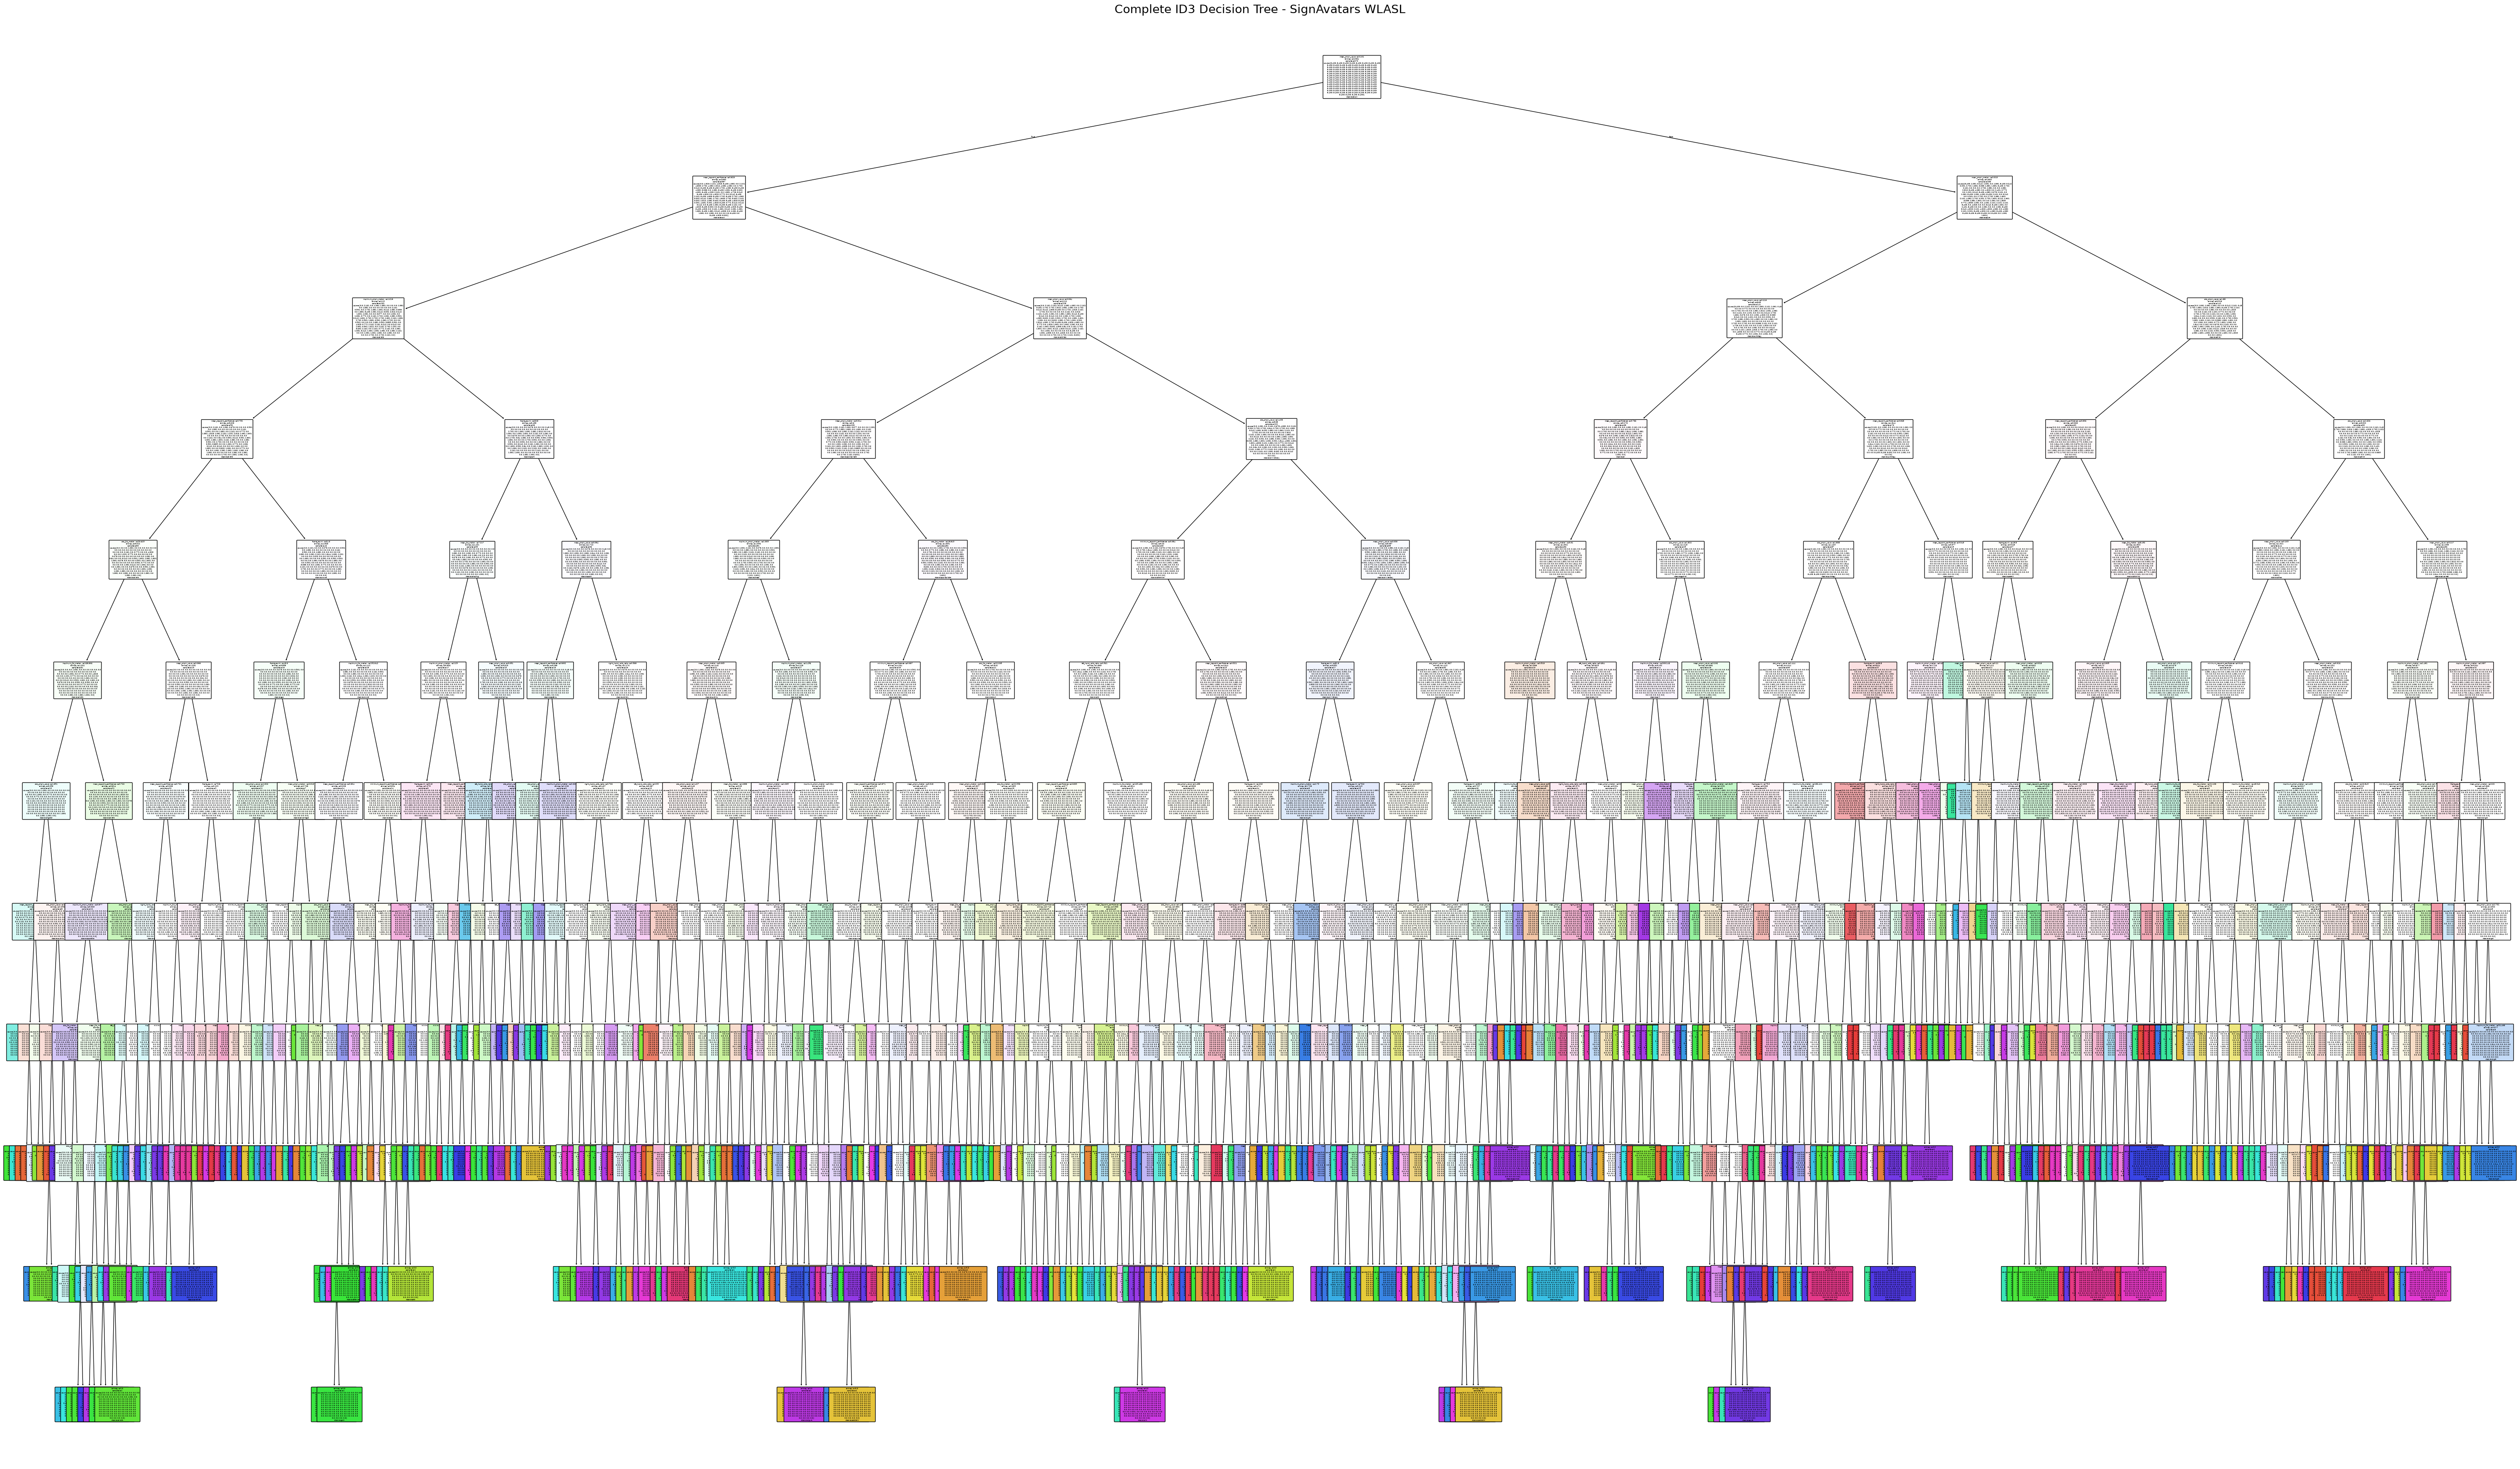

Complete tree image saved:
c:\Users\HP\OneDrive\Documents\NeuraSign\results\signavatars_wlasl_full_id3_tree.png

Complete tree rules saved:
c:\Users\HP\OneDrive\Documents\NeuraSign\results\signavatars_wlasl_full_id3_tree.txt

Tree depth: 11
Total tree nodes: 1077


In [13]:
from pathlib import Path
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt

# Set project path
project_path = Path.cwd().parent

results_folder = project_path / "results"
results_folder.mkdir(parents=True, exist_ok=True)

tree_image_path = (
    results_folder
    / "signavatars_wlasl_full_id3_tree.png"
)

tree_text_path = (
    results_folder
    / "signavatars_wlasl_full_id3_tree.txt"
)

# Create complete decision tree image
plt.figure(figsize=(60, 35))

plot_tree(
    best_model,
    feature_names=feature_columns,
    class_names=[
        str(class_name)
        for class_name in best_model.classes_
    ],
    filled=True,
    rounded=True,
    fontsize=3
)

plt.title(
    "Complete ID3 Decision Tree - SignAvatars WLASL",
    fontsize=20
)

plt.tight_layout()

plt.savefig(
    tree_image_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# Export complete tree as readable text
tree_rules = export_text(
    best_model,
    feature_names=feature_columns,
    max_depth=best_model.tree_.max_depth
)

with open(
    tree_text_path,
    "w",
    encoding="utf-8"
) as file:
    file.write(tree_rules)

print("Complete tree image saved:")
print(tree_image_path)

print("\nComplete tree rules saved:")
print(tree_text_path)

print("\nTree depth:", best_model.tree_.max_depth)
print("Total tree nodes:", best_model.tree_.node_count)

In [14]:
import json
import joblib
from pathlib import Path

# Create output folders
processed_folder = (
    project_path
    / "data"
    / "processed"
    / "signavatars_wlasl"
)

models_folder = project_path / "models"
results_folder = project_path / "results"

processed_folder.mkdir(parents=True, exist_ok=True)
models_folder.mkdir(parents=True, exist_ok=True)
results_folder.mkdir(parents=True, exist_ok=True)

# Define file paths
processed_data_path = (
    processed_folder
    / "signavatars_wlasl_model_ready.csv"
)

model_path = (
    models_folder
    / "signavatars_wlasl_id3_model.joblib"
)

imputer_path = (
    models_folder
    / "signavatars_wlasl_imputer.joblib"
)

outlier_bounds_path = (
    models_folder
    / "signavatars_wlasl_outlier_bounds.json"
)

validation_results_path = (
    results_folder
    / "signavatars_wlasl_validation_results.csv"
)

feature_importance_path = (
    results_folder
    / "signavatars_wlasl_feature_importance.csv"
)

classification_report_path = (
    results_folder
    / "signavatars_wlasl_classification_report.csv"
)

test_results_path = (
    results_folder
    / "signavatars_wlasl_test_results.json"
)

# Save processed dataset
model_df.to_csv(
    processed_data_path,
    index=False,
    encoding="utf-8"
)

# Save trained model and imputer
joblib.dump(best_model, model_path)
joblib.dump(imputer, imputer_path)

# Save outlier bounds
with open(
    outlier_bounds_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        outlier_bounds,
        file,
        indent=4
    )

# Save tabular results
validation_results_df.to_csv(
    validation_results_path,
    index=False
)

feature_importance_df.to_csv(
    feature_importance_path,
    index=False
)

class_report_df.to_csv(
    classification_report_path
)

# Prepare final result summary
final_results = {
    "dataset": "SignAvatars WLASL Word-Level Subset",
    "algorithm": "ID3 Decision Tree",
    "criterion": "entropy",
    "processing_device": str(device),
    "total_samples": int(len(model_df)),
    "number_of_classes": int(model_df["gloss"].nunique()),
    "training_samples": int(len(X_train_processed)),
    "validation_samples": int(len(X_val_processed)),
    "test_samples": int(len(X_test_processed)),
    "best_max_depth": best_parameters["max_depth"],
    "best_min_samples_leaf": best_parameters[
        "min_samples_leaf"
    ],
    "test_accuracy": float(test_accuracy),
    "test_macro_precision": float(test_precision),
    "test_macro_recall": float(test_recall),
    "test_macro_f1": float(test_f1),
    "test_top3_accuracy": float(test_top3_accuracy),
    "test_top5_accuracy": float(test_top5_accuracy),
    "tree_depth": int(best_model.tree_.max_depth),
    "tree_nodes": int(best_model.tree_.node_count),
    "features": feature_columns
}

with open(
    test_results_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        final_results,
        file,
        indent=4
    )

print("All SignAvatars files saved successfully:\n")
print("Processed data:", processed_data_path)
print("ID3 model:", model_path)
print("Imputer:", imputer_path)
print("Outlier bounds:", outlier_bounds_path)
print("Validation results:", validation_results_path)
print("Feature importance:", feature_importance_path)
print("Classification report:", classification_report_path)
print("Test results:", test_results_path)

All SignAvatars files saved successfully:

Processed data: c:\Users\HP\OneDrive\Documents\NeuraSign\data\processed\signavatars_wlasl\signavatars_wlasl_model_ready.csv
ID3 model: c:\Users\HP\OneDrive\Documents\NeuraSign\models\signavatars_wlasl_id3_model.joblib
Imputer: c:\Users\HP\OneDrive\Documents\NeuraSign\models\signavatars_wlasl_imputer.joblib
Outlier bounds: c:\Users\HP\OneDrive\Documents\NeuraSign\models\signavatars_wlasl_outlier_bounds.json
Validation results: c:\Users\HP\OneDrive\Documents\NeuraSign\results\signavatars_wlasl_validation_results.csv
Feature importance: c:\Users\HP\OneDrive\Documents\NeuraSign\results\signavatars_wlasl_feature_importance.csv
Classification report: c:\Users\HP\OneDrive\Documents\NeuraSign\results\signavatars_wlasl_classification_report.csv
Test results: c:\Users\HP\OneDrive\Documents\NeuraSign\results\signavatars_wlasl_test_results.json


In [15]:
import json
import joblib
from pathlib import Path

# Create output folders
processed_folder = (
    project_path
    / "data"
    / "processed"
    / "signavatars_wlasl"
)

models_folder = project_path / "models"
results_folder = project_path / "results"

processed_folder.mkdir(parents=True, exist_ok=True)
models_folder.mkdir(parents=True, exist_ok=True)
results_folder.mkdir(parents=True, exist_ok=True)

# Define file paths
processed_data_path = (
    processed_folder
    / "signavatars_wlasl_model_ready.csv"
)

model_path = (
    models_folder
    / "signavatars_wlasl_id3_model.joblib"
)

imputer_path = (
    models_folder
    / "signavatars_wlasl_imputer.joblib"
)

outlier_bounds_path = (
    models_folder
    / "signavatars_wlasl_outlier_bounds.json"
)

validation_results_path = (
    results_folder
    / "signavatars_wlasl_validation_results.csv"
)

feature_importance_path = (
    results_folder
    / "signavatars_wlasl_feature_importance.csv"
)

classification_report_path = (
    results_folder
    / "signavatars_wlasl_classification_report.csv"
)

test_results_path = (
    results_folder
    / "signavatars_wlasl_test_results.json"
)

# Save processed dataset
model_df.to_csv(
    processed_data_path,
    index=False,
    encoding="utf-8"
)

# Save trained model and imputer
joblib.dump(best_model, model_path)
joblib.dump(imputer, imputer_path)

# Save outlier bounds
with open(
    outlier_bounds_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        outlier_bounds,
        file,
        indent=4
    )

# Save tabular results
validation_results_df.to_csv(
    validation_results_path,
    index=False
)

feature_importance_df.to_csv(
    feature_importance_path,
    index=False
)

class_report_df.to_csv(
    classification_report_path
)

# Prepare final result summary
final_results = {
    "dataset": "SignAvatars WLASL Word-Level Subset",
    "algorithm": "ID3 Decision Tree",
    "criterion": "entropy",
    "processing_device": str(device),
    "total_samples": int(len(model_df)),
    "number_of_classes": int(model_df["gloss"].nunique()),
    "training_samples": int(len(X_train_processed)),
    "validation_samples": int(len(X_val_processed)),
    "test_samples": int(len(X_test_processed)),
    "best_max_depth": best_parameters["max_depth"],
    "best_min_samples_leaf": best_parameters[
        "min_samples_leaf"
    ],
    "test_accuracy": float(test_accuracy),
    "test_macro_precision": float(test_precision),
    "test_macro_recall": float(test_recall),
    "test_macro_f1": float(test_f1),
    "test_top3_accuracy": float(test_top3_accuracy),
    "test_top5_accuracy": float(test_top5_accuracy),
    "tree_depth": int(best_model.tree_.max_depth),
    "tree_nodes": int(best_model.tree_.node_count),
    "features": feature_columns
}

with open(
    test_results_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        final_results,
        file,
        indent=4
    )

print("All SignAvatars files saved successfully:\n")
print("Processed data:", processed_data_path)
print("ID3 model:", model_path)
print("Imputer:", imputer_path)
print("Outlier bounds:", outlier_bounds_path)
print("Validation results:", validation_results_path)
print("Feature importance:", feature_importance_path)
print("Classification report:", classification_report_path)
print("Test results:", test_results_path)

All SignAvatars files saved successfully:

Processed data: c:\Users\HP\OneDrive\Documents\NeuraSign\data\processed\signavatars_wlasl\signavatars_wlasl_model_ready.csv
ID3 model: c:\Users\HP\OneDrive\Documents\NeuraSign\models\signavatars_wlasl_id3_model.joblib
Imputer: c:\Users\HP\OneDrive\Documents\NeuraSign\models\signavatars_wlasl_imputer.joblib
Outlier bounds: c:\Users\HP\OneDrive\Documents\NeuraSign\models\signavatars_wlasl_outlier_bounds.json
Validation results: c:\Users\HP\OneDrive\Documents\NeuraSign\results\signavatars_wlasl_validation_results.csv
Feature importance: c:\Users\HP\OneDrive\Documents\NeuraSign\results\signavatars_wlasl_feature_importance.csv
Classification report: c:\Users\HP\OneDrive\Documents\NeuraSign\results\signavatars_wlasl_classification_report.csv
Test results: c:\Users\HP\OneDrive\Documents\NeuraSign\results\signavatars_wlasl_test_results.json
